# Идеальный пример экзаменационной тетрадки


**Пример выполнен на другом датасете**: `wine_exam_example_dirty.csv` — классификация типа вина по химическим характеристикам.  
Тетрадка специально повторяет типичные проблемы экзаменационного датасета:

1. В категориальном признаке `AlcoholLevel` есть 5 «грязных» значений: вместо слов `low / medium / high` стоят случайные числа.
2. Целевая переменная `WineClass` записана буквами: `A`, `B`, `C`.
3. В трёх числовых колонках есть пропуски: `alcohol`, `color_intensity`, `proline`.
4. В датасете есть 5 продублированных строк.
5. Есть технический идентификатор `SampleID` и признак `TargetCodeLeak`, который является утечкой целевой переменной и должен быть исключён.

> Это пример того, как должна выглядеть аккуратная, полная и аргументированная работа студента: код, комментарии, проверки, визуализации, модели, метрики, оптимизация и сохранение итоговой модели.

# 0. Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

## 1. Загрузка данных и первичный осмотр структуры

На этом этапе важно не просто вывести `head()`, а описать размер таблицы, типы данных, целевую переменную, пропуски, дубликаты и потенциально проблемные признаки.

In [2]:
DATA_PATH = 'wine_exam_example_dirty.csv'

try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    df = pd.read_csv('/mnt/data/wine_exam_example_dirty.csv')

print('Размер датасета:', df.shape)
df.head()

Размер датасета: (183, 17)


,SampleID,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,WineClass,TargetCodeLeak,AlcoholLevel
0,1020,13.64,3.10,2.56,15.2,116.0,2.70,3.03,0.17,1.66,5.10,0.96,3.36,845.0,A,0,high
1,1043,13.88,1.89,2.59,15.0,101.0,3.25,3.56,0.17,1.70,5.43,0.88,3.56,1095.0,A,0,high
2,1156,13.17,5.19,2.32,22.0,93.0,1.74,0.63,0.61,1.55,7.90,0.60,1.48,NaN,C,2,medium
3,1112,12.52,2.43,2.17,21.0,88.0,2.55,2.27,0.26,1.22,2.00,0.90,2.78,325.0,B,1,medium
4,1148,12.87,4.61,2.48,21.5,86.0,1.70,0.65,0.47,0.86,7.65,0.54,1.86,625.0,C,2,medium


In [3]:
print('Информация о датасете:')
df.info()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   SampleID                      183 non-null    int64  
 1   alcohol                       175 non-null    float64
 2   malic_acid                    183 non-null    float64
 3   ash                           183 non-null    float64
 4   alcalinity_of_ash             183 non-null    float64
 5   magnesium                     183 non-null    float64
 6   total_phenols                 183 non-null    float64
 7   flavanoids                    183 non-null    float64
 8   nonflavanoid_phenols          183 non-null    float64
 9   proanthocyanins               183 non-null    float64
 10  color_intensity               176 non-null    float64
 11  hue                           183 non-null    float64
 12  od280/od315_of_diluted_wines  183 non-nul

In [4]:
print('Количество пропусков по столбцам:')
df.isna().sum().sort_values(ascending=False)

Количество пропусков по столбцам:


,0
proline,10
alcohol,8
color_intensity,7
SampleID,0
malic_acid,0
magnesium,0
total_phenols,0
ash,0
alcalinity_of_ash,0
nonflavanoid_phenols,0


# 2. Предобработка данных

В этом разделе выполняется очистка данных:

- удаление дубликатов;
- обработка грязных категориальных значений;
- удаление признаков, которые нельзя использовать для обучения;
- проверка пропусков;
- подготовка целевой переменной.

Важно: числовые пропуски и категориальные пропуски далее будут обработаны внутри `Pipeline`, чтобы не было утечки данных из валидационной выборки.

In [5]:
# Копируем исходный датафрейм, чтобы не портить оригинальные данные
clean_df = df.copy()

print('Количество строк до удаления дубликатов:', clean_df.shape[0])
print('Количество полных дубликатов:', clean_df.duplicated().sum())

clean_df = clean_df.drop_duplicates()

print('Количество строк после удаления дубликатов:', clean_df.shape[0])

Количество строк до удаления дубликатов: 183
Количество полных дубликатов: 5
Количество строк после удаления дубликатов: 178


In [6]:
# Посмотрим уникальные значения категориальных признаков
cat_cols_initial = clean_df.select_dtypes(include='object').columns

for col in cat_cols_initial:
    print(f'{col}:', clean_df[col].unique())

WineClass: ['A' 'C' 'B']
AlcoholLevel: ['high' 'medium' '42' 'low' '777' '999']


In [7]:
# Пример обработки грязных категориальных данных.
# В признаке AlcoholLevel могут быть значения low, medium, high и случайные грязные значения.
# Всё, что не входит в допустимый список, заменяем на NaN.

if 'AlcoholLevel' in clean_df.columns:
    allowed_levels = ['low', 'medium', 'high']
    clean_df['AlcoholLevel'] = clean_df['AlcoholLevel'].where(
        clean_df['AlcoholLevel'].isin(allowed_levels),
        np.nan
    )

print('Уникальные значения AlcoholLevel после очистки:')
print(clean_df['AlcoholLevel'].unique() if 'AlcoholLevel' in clean_df.columns else 'Признак отсутствует')

Уникальные значения AlcoholLevel после очистки:
['high' 'medium' nan 'low']


In [8]:
# Удаляем признаки, которые не должны использоваться при обучении.
# SampleID — технический идентификатор строки.
# TargetCodeLeak — утечка целевой переменной, так как напрямую связан с классом.

drop_cols = []

for col in ['SampleID', 'TargetCodeLeak']:
    if col in clean_df.columns:
        drop_cols.append(col)

clean_df = clean_df.drop(columns=drop_cols)

print('Удалённые признаки:', drop_cols)
print('Размер после удаления лишних признаков:', clean_df.shape)

Удалённые признаки: ['SampleID', 'TargetCodeLeak']
Размер после удаления лишних признаков: (178, 15)


In [9]:
# Проверим целевую переменную
print('Распределение классов:')
print(clean_df['WineClass'].value_counts())

Распределение классов:
WineClass
B    71
A    59
C    48
Name: count, dtype: int64


# 3. Анализ EDA

EDA должен показывать не просто графики, а связь признаков с целевой переменной. Ниже приведены обязательные блоки: распределение целевой переменной, распределения числовых признаков, boxplot по классам, корреляционная матрица.

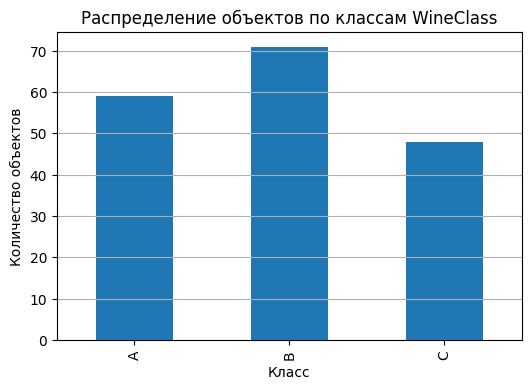

In [10]:
# Распределение целевой переменной
plt.figure(figsize=(6, 4))
clean_df['WineClass'].value_counts().sort_index().plot(kind='bar')
plt.title('Распределение объектов по классам WineClass')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.grid(axis='y')
plt.show()

In [11]:
# Описательная статистика числовых признаков
clean_df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,170.0,13.005176,0.817320,11.03,12.3450,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,171.0,5.066608,2.343109,1.28,3.2300,4.680,6.2250,13.00


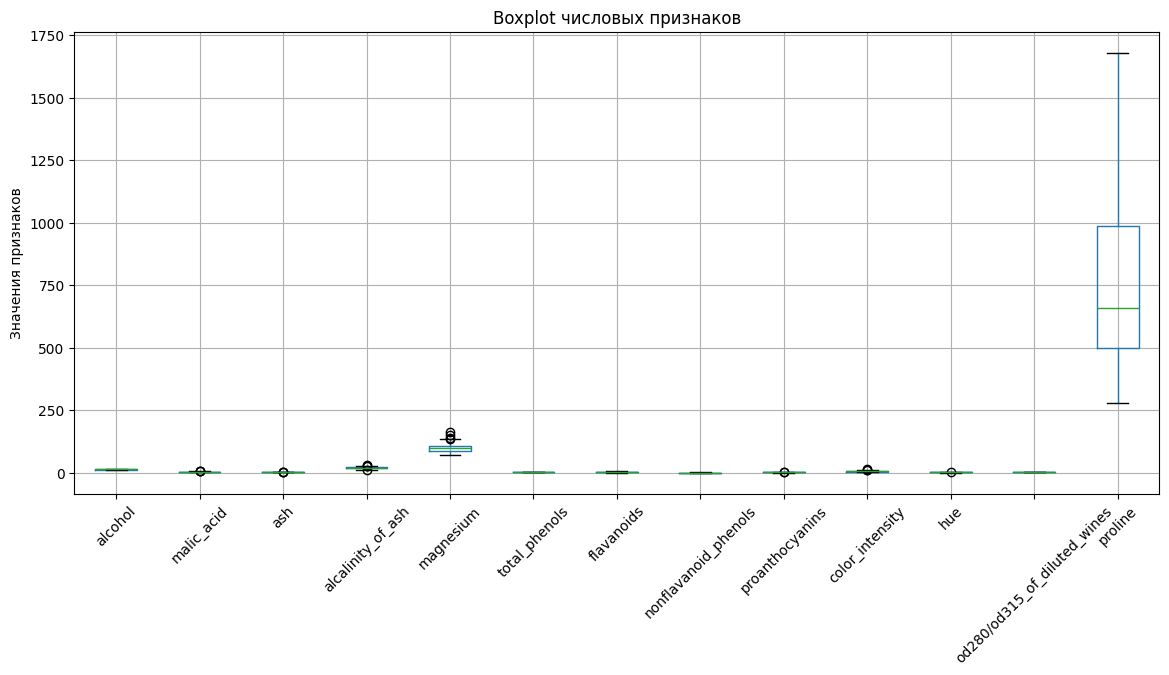

In [12]:
# Boxplot числовых признаков для поиска потенциальных выбросов
numeric_cols = clean_df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(14, 6))
clean_df[numeric_cols].boxplot(rot=45)
plt.title('Boxplot числовых признаков')
plt.ylabel('Значения признаков')
plt.grid(True)
plt.show()

<Figure size 700x500 with 0 Axes>

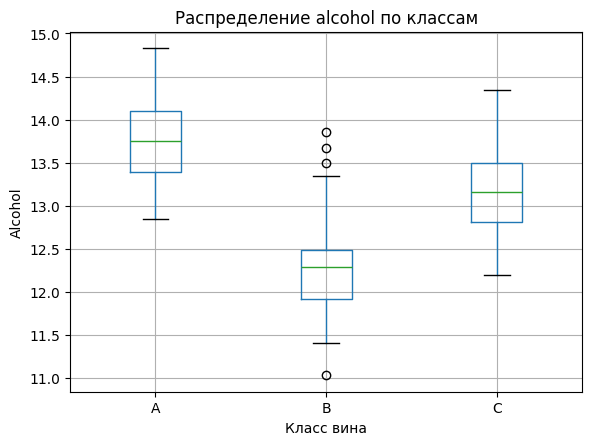

In [13]:
# Boxplot одного важного признака по классам
if 'alcohol' in clean_df.columns:
    plt.figure(figsize=(7, 5))
    clean_df.boxplot(column='alcohol', by='WineClass', grid=True)
    plt.title('Распределение alcohol по классам')
    plt.suptitle('')
    plt.xlabel('Класс вина')
    plt.ylabel('Alcohol')
    plt.show()

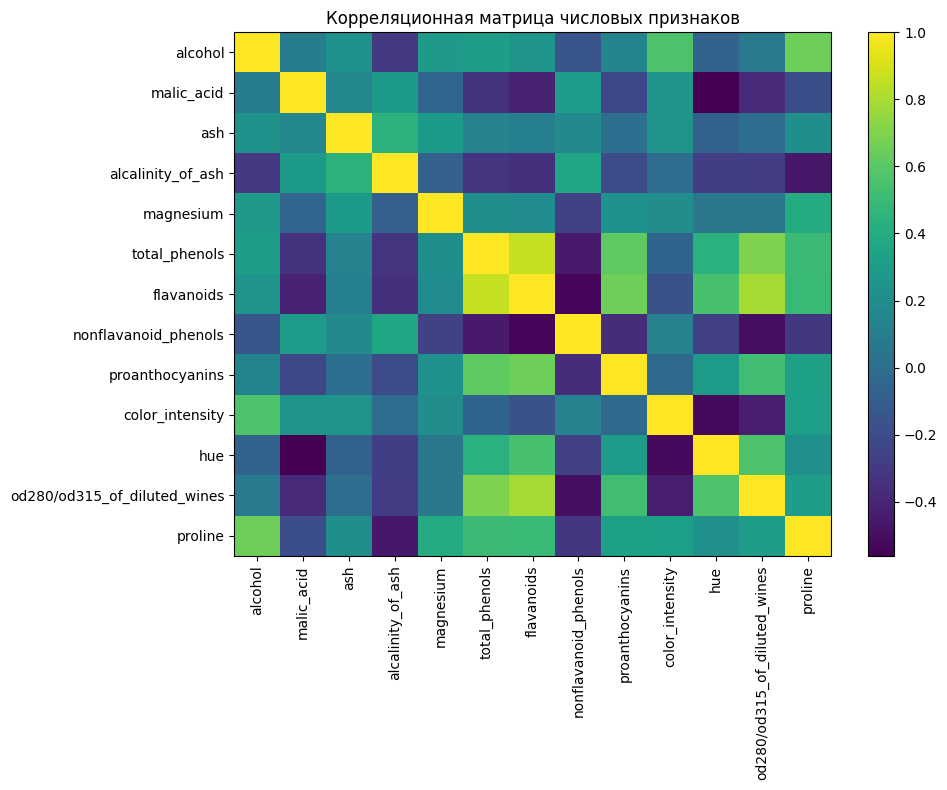

In [14]:
# Корреляционная матрица числовых признаков
corr = clean_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()

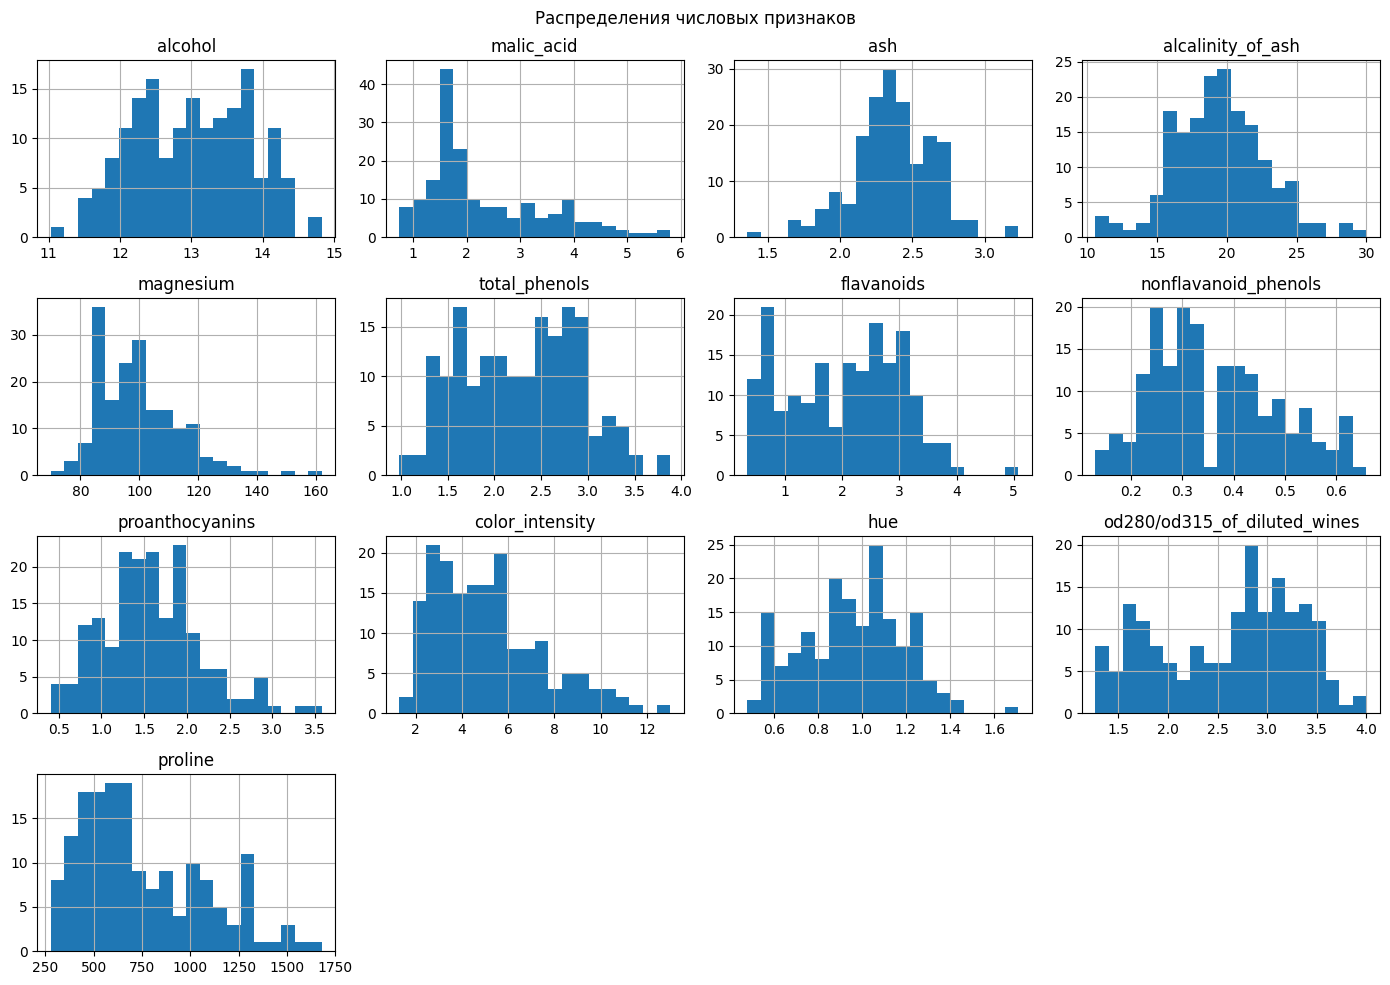

In [15]:
# Гистограммы числовых признаков
clean_df[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle('Распределения числовых признаков')
plt.tight_layout()
plt.show()

# 4. Набор данных

Формируем матрицу признаков `X` и целевую переменную `y`.  
Целевую переменную кодируем в числа, потому что модели машинного обучения работают с числовыми метками классов.

Далее выполняем разбиение на обучающую и валидационную выборки.

In [16]:
TARGET = 'WineClass'

X = clean_df.drop(columns=[TARGET])
y = clean_df[TARGET]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print('Классы:', list(label_encoder.classes_))
print('Размер X:', X.shape)
print('Размер y:', y_encoded.shape)

Классы: ['A', 'B', 'C']
Размер X: (178, 14)
Размер y: (178,)


In [17]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded
)

print('Размер обучающей выборки:', X_train.shape)
print('Размер валидационной выборки:', X_valid.shape)

Размер обучающей выборки: (133, 14)
Размер валидационной выборки: (45, 14)


In [18]:
# Выделяем числовые и категориальные признаки
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print('Числовые признаки:', numeric_features)
print('Категориальные признаки:', categorical_features)

Числовые признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Категориальные признаки: ['AlcoholLevel']


In [19]:
# Универсальная предобработка:
# - для числовых признаков: заполнение пропусков медианой + стандартизация;
# - для категориальных признаков: заполнение самым частым значением + one-hot encoding.

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 5. Построение логистической регрессии

Логистическая регрессия используется как базовая интерпретируемая модель классификации.

In [20]:
log_reg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=5000, random_state=42))
])

log_reg_model.fit(X_train, y_train)

y_pred_lr = log_reg_model.predict(X_valid)

print('Accuracy Logistic Regression:', accuracy_score(y_valid, y_pred_lr))
print(classification_report(y_valid, y_pred_lr, target_names=label_encoder.classes_))

Accuracy Logistic Regression: 0.9333333333333333
              precision    recall  f1-score   support

           A       0.88      1.00      0.94        15
           B       1.00      0.83      0.91        18
           C       0.92      1.00      0.96        12

    accuracy                           0.93        45
   macro avg       0.94      0.94      0.94        45
weighted avg       0.94      0.93      0.93        45



# 6. Оптимизация логистической регрессии

Оптимизируем логистическую регрессию с помощью `GridSearchCV`.  
Подбираем:

- `C` — силу регуляризации;
- `penalty` — тип регуляризации;
- `solver` — алгоритм оптимизации.

Маленькое `C` означает сильную регуляризацию, большое `C` — слабую регуляризацию.

In [21]:
param_grid_lr = [
    {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['liblinear']
    },
    {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs']
    }
]

grid_lr = GridSearchCV(
    estimator=log_reg_model,
    param_grid=param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print('Лучшие параметры Logistic Regression:')
print(grid_lr.best_params_)
print('Лучшая accuracy на кросс-валидации:', grid_lr.best_score_)

y_pred_lr_opt = grid_lr.predict(X_valid)

print('Accuracy оптимизированной Logistic Regression:', accuracy_score(y_valid, y_pred_lr_opt))
print(classification_report(y_valid, y_pred_lr_opt, target_names=label_encoder.classes_))

Лучшие параметры Logistic Regression:
{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Лучшая accuracy на кросс-валидации: 0.9777777777777779
Accuracy оптимизированной Logistic Regression: 0.9333333333333333
              precision    recall  f1-score   support

           A       0.88      1.00      0.94        15
           B       1.00      0.83      0.91        18
           C       0.92      1.00      0.96        12

    accuracy                           0.93        45
   macro avg       0.94      0.94      0.94        45
weighted avg       0.94      0.93      0.93        45



# 7. Графики логистической регрессии

Для логистической регрессии строим:

1. матрицу ошибок;
2. кривую валидации по параметру `C`;
3. кривую обучения.

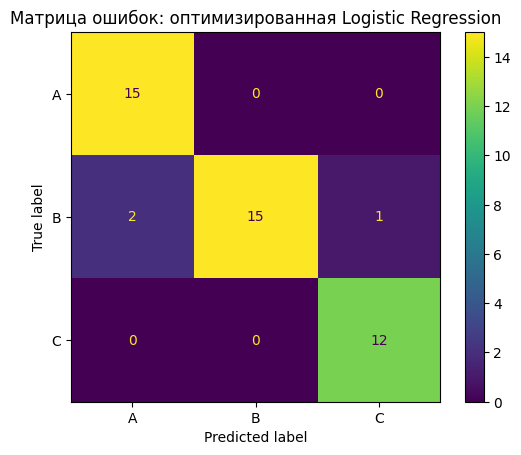

In [22]:
cm_lr = confusion_matrix(y_valid, y_pred_lr_opt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title('Матрица ошибок: оптимизированная Logistic Regression')
plt.show()

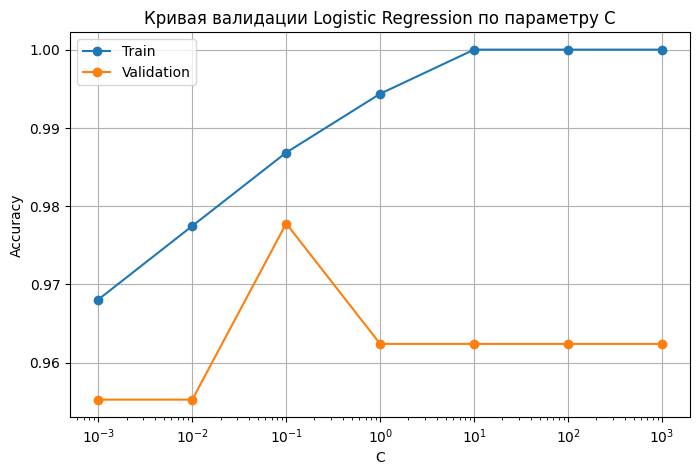

In [23]:
param_range_C = np.logspace(-3, 3, 7)

train_scores_lr, valid_scores_lr = validation_curve(
    estimator=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=5000, solver='liblinear', penalty='l2', random_state=42))
    ]),
    X=X_train,
    y=y_train,
    param_name='model__C',
    param_range=param_range_C,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean_lr = train_scores_lr.mean(axis=1)
valid_mean_lr = valid_scores_lr.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(param_range_C, train_mean_lr, marker='o', label='Train')
plt.semilogx(param_range_C, valid_mean_lr, marker='o', label='Validation')
plt.title('Кривая валидации Logistic Regression по параметру C')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

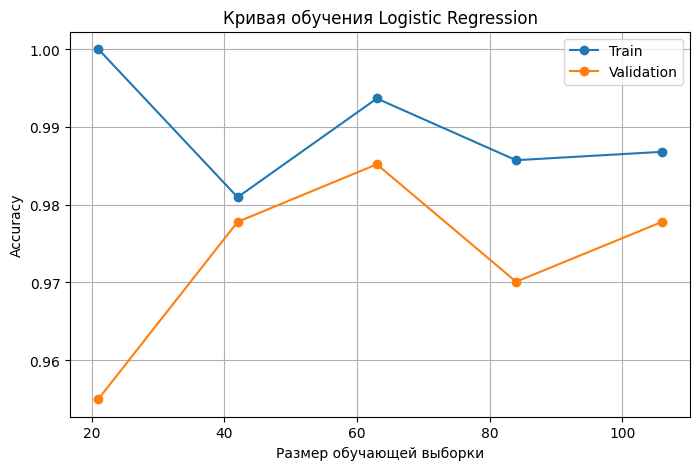

In [24]:
train_sizes_lr, train_scores_lc_lr, valid_scores_lc_lr = learning_curve(
    estimator=grid_lr.best_estimator_,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.2, 1.0, 5)
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_lr, train_scores_lc_lr.mean(axis=1), marker='o', label='Train')
plt.plot(train_sizes_lr, valid_scores_lc_lr.mean(axis=1), marker='o', label='Validation')
plt.title('Кривая обучения Logistic Regression')
plt.xlabel('Размер обучающей выборки')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 8. Нейронная модель

В качестве нейронной модели используется `MLPClassifier` — многослойный перцептрон.  
Это простая полносвязная нейронная сеть для табличных данных.

In [25]:
mlp_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_valid)

print('Accuracy MLP:', accuracy_score(y_valid, y_pred_mlp))
print(classification_report(y_valid, y_pred_mlp, target_names=label_encoder.classes_))

Accuracy MLP: 0.6666666666666666
              precision    recall  f1-score   support

           A       0.62      1.00      0.77        15
           B       1.00      0.17      0.29        18
           C       0.67      1.00      0.80        12

    accuracy                           0.67        45
   macro avg       0.76      0.72      0.62        45
weighted avg       0.79      0.67      0.58        45



# 9. Оптимизация нейронной модели

Оптимизируем нейронную сеть с помощью `GridSearchCV`.  
Подбираем:

- размер скрытых слоёв;
- функцию активации;
- `alpha` — коэффициент L2-регуляризации;
- скорость обучения.

Цель — получить хорошее качество без переобучения.

In [26]:
param_grid_mlp = {
    'model__hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64)],
    'model__activation': ['relu', 'tanh'],
    'model__alpha': [0.0001, 0.001, 0.01],
    'model__learning_rate_init': [0.001, 0.005]
}

grid_mlp = GridSearchCV(
    estimator=mlp_model,
    param_grid=param_grid_mlp,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_mlp.fit(X_train, y_train)

print('Лучшие параметры MLP:')
print(grid_mlp.best_params_)
print('Лучшая accuracy на кросс-валидации:', grid_mlp.best_score_)

y_pred_mlp_opt = grid_mlp.predict(X_valid)

print('Accuracy оптимизированной MLP:', accuracy_score(y_valid, y_pred_mlp_opt))
print(classification_report(y_valid, y_pred_mlp_opt, target_names=label_encoder.classes_))

Лучшие параметры MLP:
{'model__activation': 'tanh', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': 0.005}
Лучшая accuracy на кросс-валидации: 0.9547008547008546
Accuracy оптимизированной MLP: 0.8888888888888888
              precision    recall  f1-score   support

           A       0.88      0.93      0.90        15
           B       1.00      0.78      0.88        18
           C       0.80      1.00      0.89        12

    accuracy                           0.89        45
   macro avg       0.89      0.90      0.89        45
weighted avg       0.91      0.89      0.89        45



# 10. Графики нейронной модели

Для нейронной сети строим:

1. матрицу ошибок;
2. кривую валидации по `alpha`;
3. кривую обучения;
4. график функции потерь.

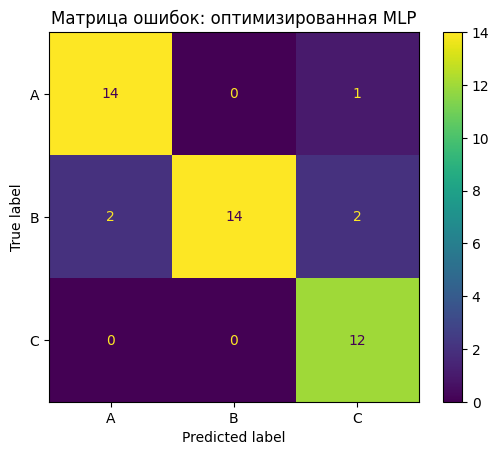

In [27]:
cm_mlp = confusion_matrix(y_valid, y_pred_mlp_opt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title('Матрица ошибок: оптимизированная MLP')
plt.show()

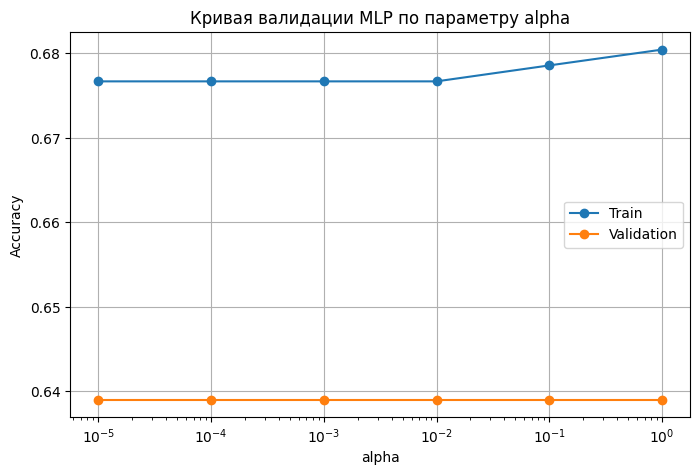

In [28]:
param_range_alpha = np.logspace(-5, 0, 6)

train_scores_mlp, valid_scores_mlp = validation_curve(
    estimator=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            max_iter=1000,
            early_stopping=True,
            random_state=42
        ))
    ]),
    X=X_train,
    y=y_train,
    param_name='model__alpha',
    param_range=param_range_alpha,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean_mlp = train_scores_mlp.mean(axis=1)
valid_mean_mlp = valid_scores_mlp.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(param_range_alpha, train_mean_mlp, marker='o', label='Train')
plt.semilogx(param_range_alpha, valid_mean_mlp, marker='o', label='Validation')
plt.title('Кривая валидации MLP по параметру alpha')
plt.xlabel('alpha')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

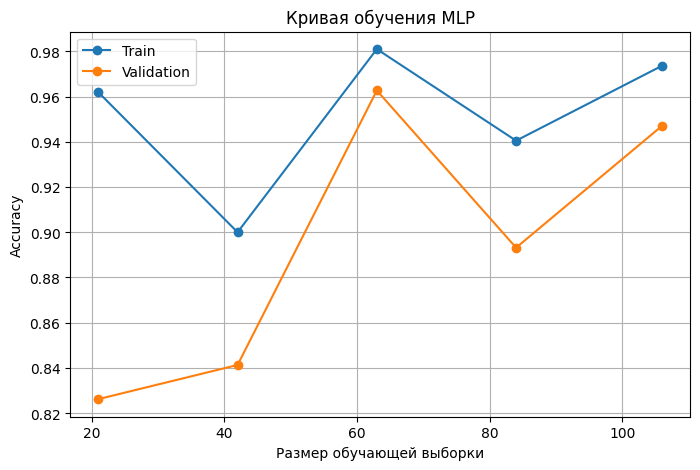

In [29]:
train_sizes_mlp, train_scores_lc_mlp, valid_scores_lc_mlp = learning_curve(
    estimator=grid_mlp.best_estimator_,
    X=X_train,
    y=y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.2, 1.0, 5)
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes_mlp, train_scores_lc_mlp.mean(axis=1), marker='o', label='Train')
plt.plot(train_sizes_mlp, valid_scores_lc_mlp.mean(axis=1), marker='o', label='Validation')
plt.title('Кривая обучения MLP')
plt.xlabel('Размер обучающей выборки')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

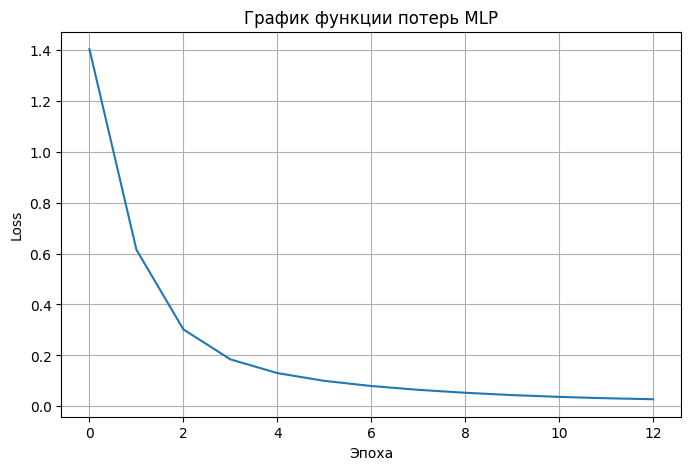

In [30]:
# График функции потерь лучшей нейронной сети
best_mlp = grid_mlp.best_estimator_.named_steps['model']

plt.figure(figsize=(8, 5))
plt.plot(best_mlp.loss_curve_)
plt.title('График функции потерь MLP')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [31]:
# Сравнение качества моделей
results = pd.DataFrame({
    'Модель': [
        'Logistic Regression',
        'Optimized Logistic Regression',
        'MLP',
        'Optimized MLP'
    ],
    'Accuracy': [
        accuracy_score(y_valid, y_pred_lr),
        accuracy_score(y_valid, y_pred_lr_opt),
        accuracy_score(y_valid, y_pred_mlp),
        accuracy_score(y_valid, y_pred_mlp_opt)
    ]
})

results

,Модель,Accuracy
0,Logistic Regression,0.933333
1,Optimized Logistic Regression,0.933333
2,MLP,0.666667
3,Optimized MLP,0.888889


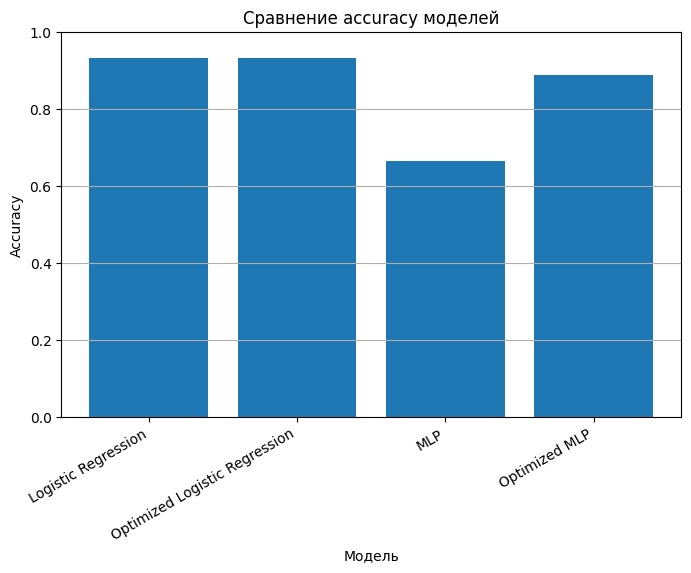

In [32]:
plt.figure(figsize=(8, 5))
plt.bar(results['Модель'], results['Accuracy'])
plt.title('Сравнение accuracy моделей')
plt.xlabel('Модель')
plt.ylabel('Accuracy')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

# 11. Сохранение модели

Сохраняем лучшую модель.  
Если нейронная сеть показала качество не хуже логистической регрессии, сохраняем её. Иначе сохраняем логистическую регрессию.

In [33]:
acc_lr_opt = accuracy_score(y_valid, y_pred_lr_opt)
acc_mlp_opt = accuracy_score(y_valid, y_pred_mlp_opt)

if acc_mlp_opt >= acc_lr_opt:
    best_model = grid_mlp.best_estimator_
    best_model_name = 'optimized_mlp'
    best_accuracy = acc_mlp_opt
else:
    best_model = grid_lr.best_estimator_
    best_model_name = 'optimized_logistic_regression'
    best_accuracy = acc_lr_opt

print('Лучшая модель:', best_model_name)
print('Accuracy лучшей модели:', best_accuracy)

joblib.dump(best_model, 'best_exam_model.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

print('Модель сохранена в файл best_exam_model.pkl')
print('Кодировщик целевой переменной сохранён в файл label_encoder.pkl')

Лучшая модель: optimized_logistic_regression
Accuracy лучшей модели: 0.9333333333333333
Модель сохранена в файл best_exam_model.pkl
Кодировщик целевой переменной сохранён в файл label_encoder.pkl


In [34]:
# Проверка загрузки сохранённой модели
loaded_model = joblib.load('best_exam_model.pkl')
loaded_encoder = joblib.load('label_encoder.pkl')

sample_prediction = loaded_model.predict(X_valid.head(5))
print('Предсказания для первых 5 объектов:', loaded_encoder.inverse_transform(sample_prediction))

Предсказания для первых 5 объектов: ['A' 'C' 'A' 'A' 'B']


# Итоговый вывод

В работе была выполнена полная цепочка решения задачи классификации:

- данные загружены и очищены;
- удалены дубликаты и признаки с утечкой целевой переменной;
- проведён EDA;
- выполнено разбиение на обучающую и валидационную выборки;
- построены две модели: логистическая регрессия и нейронная сеть;
- выполнена оптимизация обеих моделей;
- построены матрицы ошибок, кривые валидации и кривые обучения;
- выбрана и сохранена лучшая модель.

